In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from setup import device, train_test_split_path, Sequence_dataset
_, _, X_eval_path, _, _, y_eval = train_test_split_path()
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

In [2]:
class gruclassf(nn.Module):
    def __init__(self, seq_len, hidden_size):
        super().__init__()
        self.GRU1 = nn.GRU(input_size=seq_len, hidden_size=hidden_size, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(2*hidden_size, 1)
        self.Linear = nn.Linear(in_features=2*hidden_size, out_features=10)

    def forward(self, input_seq):
        # input_seq: (batch, time, features)
        out, _ = self.GRU1(input_seq)
        # attention
        attn_weights = torch.softmax(self.attn(out).squeeze(-1), dim=1)  # (batch, time)
        context = torch.sum(out * attn_weights.unsqueeze(-1), dim=1)     # (batch, 2*hidden_size)
        outputs = self.Linear(context)
        return outputs

In [5]:
def get_data_eval(feature_name, dataset_class):
    X_eval = np.load(f'../Data/X_eval_{feature_name}.npy') 

    print(f"Evaluacion: {len(X_eval)} pares")
    print("-" * 50)

    if feature_name == 'EnCodecMAE':
        # venia (719, 1, 1031, 768) -> (719, 1031, 768) -> (719, 768, 1031) ~ (N, seq_len, timesteps)
        X_eval = X_eval.squeeze(1).transpose(0, 2, 1)

    eval_dataset = dataset_class(X_eval, y_eval)

    print('Primer elemento del dataset de evaluacion:', eval_dataset[0])
    print("-" * 50)

    return eval_dataset

FEATURE = "EnCodecMAE"
eval_dataset = get_data_eval(FEATURE, Sequence_dataset)

Evaluacion: 100 pares
--------------------------------------------------
Primer elemento del dataset de evaluacion: {'input': tensor([[ 0.0788, -0.3089, -0.1675,  ..., -0.4633, -0.0518, -0.2444],
        [ 0.2202, -0.3133, -0.0961,  ..., -0.0660, -0.0521,  0.1423],
        [ 0.1590, -0.3275, -0.0449,  ..., -0.2749,  0.0754,  0.2527],
        ...,
        [-0.0547,  0.1751, -0.0496,  ..., -0.1884, -0.0675, -0.1811],
        [-0.0564,  0.2788,  0.1230,  ..., -0.2253, -0.2546, -0.4821],
        [-0.0632, -0.1581,  0.1719,  ...,  0.0329,  0.1492,  0.1147]],
       device='cuda:0'), 'target': tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.], device='cuda:0'), 'input_length': (1031, 768), 'target_length': 10}
--------------------------------------------------


In [10]:
PATH_MODEL = "../Models/rnns_modelo4_EnCodecMAE.pth"
HIDDEN_SIZE = 32
SEQ_LEN = eval_dataset[0]['input_length'][1]

model = gruclassf(seq_len=SEQ_LEN, hidden_size=HIDDEN_SIZE).to(device)
model.load_state_dict(torch.load(PATH_MODEL))

<All keys matched successfully>

In [15]:
BATCH_SIZE = 32
eval_dataloader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# calcula las predicciones de X_eval
model.eval()
y_pred = []
y_pred_probs = []
with torch.inference_mode():
    for batch_idx, batch in enumerate(eval_dataloader):
        input = batch['input']
        output = model.forward(input)
        probs = torch.softmax(output, dim=1)
        y_pred += torch.argmax(output, dim=1).cpu().tolist()
        y_pred_probs += probs.cpu().tolist()

print(y_pred)
print(y_pred_probs[0]) # probabilidades del la primera muestra

[6, 1, 9, 2, 1, 0, 4, 2, 0, 6, 2, 5, 2, 5, 6, 1, 0, 4, 1, 2, 8, 0, 1, 7, 4, 6, 1, 5, 8, 8, 8, 3, 0, 7, 6, 9, 1, 5, 1, 9, 5, 4, 9, 6, 3, 2, 5, 3, 4, 4, 2, 7, 3, 3, 4, 8, 8, 8, 8, 5, 0, 4, 4, 9, 3, 6, 3, 0, 7, 2, 8, 0, 7, 4, 8, 7, 9, 2, 3, 3, 4, 9, 5, 6, 0, 6, 4, 7, 2, 3, 8, 5, 6, 1, 7, 5, 0, 1, 6, 2]
[0.0004989883746020496, 0.0008460834505967796, 0.00014148712216410786, 0.0009062886820174754, 0.0018437823746353388, 0.0005169518990442157, 0.9919666647911072, 0.0001530846202513203, 2.735572707024403e-05, 0.0030993090476840734]


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_true=y_eval, y_pred=y_pred, target_names=genres))

              precision    recall  f1-score   support

       blues       0.90      0.90      0.90        10
   classical       1.00      1.00      1.00        10
     country       0.73      0.80      0.76        10
       disco       0.90      0.90      0.90        10
      hiphop       0.75      0.90      0.82        10
        jazz       1.00      1.00      1.00        10
       metal       0.91      1.00      0.95        10
         pop       0.88      0.70      0.78        10
      reggae       0.82      0.90      0.86        10
        rock       0.57      0.40      0.47        10

    accuracy                           0.85       100
   macro avg       0.85      0.85      0.84       100
weighted avg       0.85      0.85      0.84       100



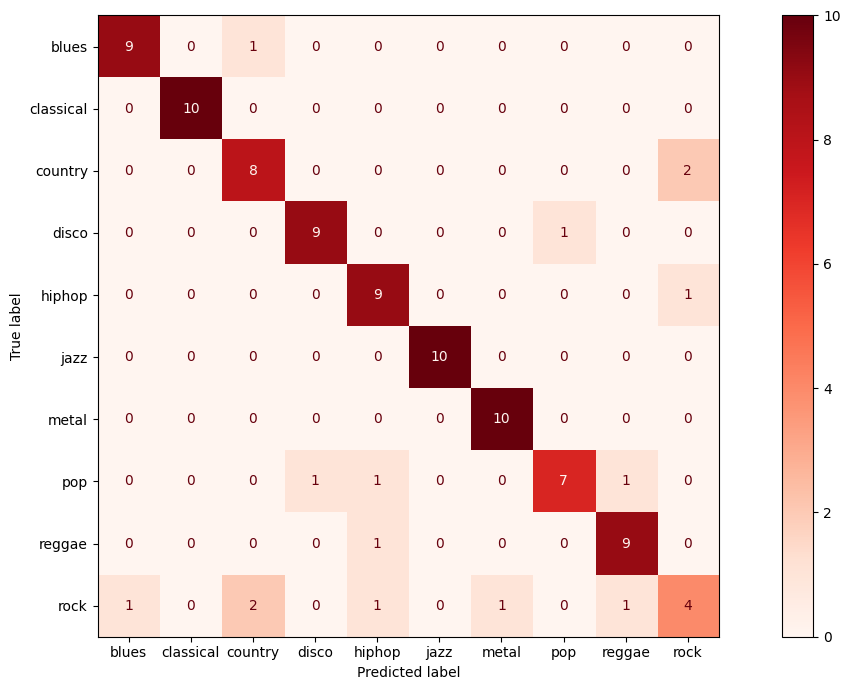

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(13, 7))
ConfusionMatrixDisplay.from_predictions(y_true=y_eval, y_pred=y_pred, cmap='Reds', display_labels=genres, ax=ax)
plt.tight_layout()
plt.show()